In [ ]:
from pathlib import Path
import sys

import numpy as np
import math,random,os,sys, importlib, time
ROOT = Path.cwd().resolve().parents[0]
SRC  = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


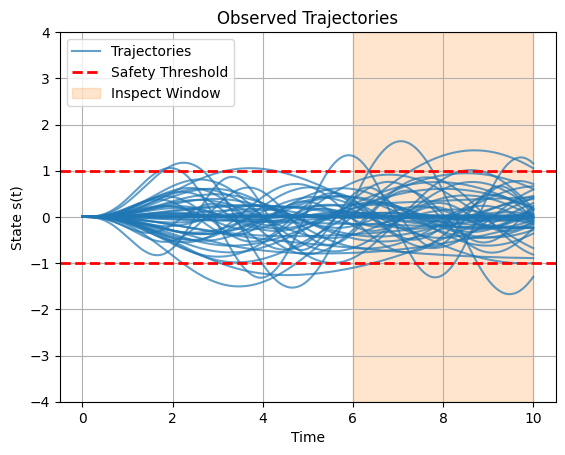

In [22]:
import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
from data.utils import plot_traj, check_safety, plot_x_safety_map


z_0 = np.array([0.0, 0.0])  # baseline configuration
params = SpringParams(mass=1.0, damping=1, stiffness=2.0) # system parameters
mean = np.array([0,0]); cov = np.diag([1.4, 1.4]) # parameters of the X distribution

tau = 1 # safety upper threshold for trajectory
time_window = (6, 10) # inspection window
T = 10; dt = 0.01 # t \in [0,T] with step dt = 0.01
seed = 1 # random seed


X = sample_x(n_samples = 10000, dist_type="gaussian", params={"mean": mean, "cov": cov}, seed=seed)

###### return a dict with keys: dict_keys(['t', 's', 's_dot']), time (T array), position (n * T array), velocity (n * T array)
traj = simulate_spring(params, t_final=T, dt=dt, X=X, forcing_type='sin', config=z_0)
plot_traj(traj, threshold=tau, window=time_window,n_max=50,title='Observed Trajectories',ylim=(-4,4))

### in real data only observe X and traj['s], traj['s_dot]

In [23]:
# Check whether current configuration is safe under baseline N(mean, cov)
# safety_indicator = 1 if safe, 0 if unsafe
eta = 0.1
safety_indicator = check_safety(traj, threshold=tau, window=time_window)

p_safe = float(np.mean(safety_indicator))
print(f"Empirical safety probability: {p_safe:.4f}")

config_safety = 1 if p_safe >= 1.0 - eta else 0  # chance constraint
print(f"Chance constraint threshold (1-eta) = {1.0 - eta:.4f} -> config_safety = {config_safety}")


Empirical safety probability: 0.9009
Chance constraint threshold (1-eta) = 0.9000 -> config_safety = 1


Empirical safety probability=0.8121 vs threshold 0.9000 (eta=0.1000) -> UNSAFE


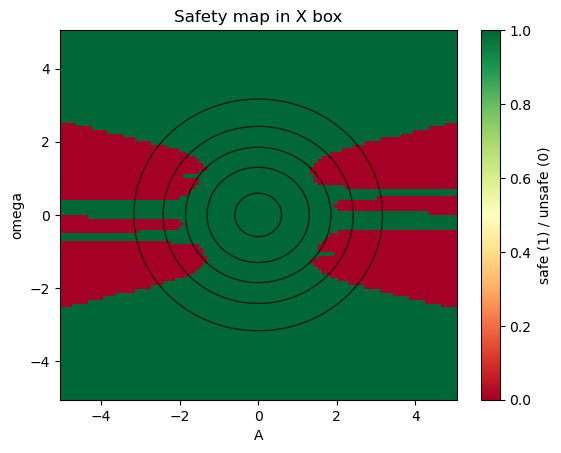

In [6]:
mean_test = np.array([0,0])
cov_test = np.diag([3, 3])

safe_grid_dict = plot_x_safety_map(
    params, t_final=T, dt=dt, window=time_window, threshold=tau,
    n_grid=100, box_limits=(-5, 5), forcing_type="sin", config=z_0,
    mean=mean_test, cov=cov_test, contour_levels=5, contour_color="black", contour_alpha=0.7,
    eta=0.1, print_msg=True,
)